## Blood Donation Prediction – Data Analysis Problem Statement

The objective of this project is to analyze historical blood donation data and build a predictive model to determine whether a donor will donate blood again in March 2007.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
%matplotlib inline

In [15]:
df = pd.read_csv("Warm_Up_Predict_Blood_Donations_-_Traning_Data.csv")
df.head()

,Unnamed: 0,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
0,619,2,50,12500,98,1
1,664,0,13,3250,28,1
2,441,1,16,4000,35,1
3,160,2,20,5000,45,1
4,358,1,24,6000,77,0


In [16]:
df.shape

(576, 6)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Unnamed: 0                   576 non-null    int64
 1   Months since Last Donation   576 non-null    int64
 2   Number of Donations          576 non-null    int64
 3   Total Volume Donated (c.c.)  576 non-null    int64
 4   Months since First Donation  576 non-null    int64
 5   Made Donation in March 2007  576 non-null    int64
dtypes: int64(6)
memory usage: 27.1 KB


In [18]:
df.describe()

,Unnamed: 0,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
count,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000
mean,374.034722,9.439236,5.427083,1356.770833,34.050347,0.239583
std,216.947773,8.175454,5.740010,1435.002556,24.227672,0.427200
min,0.000000,0.000000,1.000000,250.000000,2.000000,0.000000
25%,183.750000,2.000000,2.000000,500.000000,16.000000,0.000000
50%,375.500000,7.000000,4.000000,1000.000000,28.000000,0.000000
75%,562.500000,14.000000,7.000000,1750.000000,49.250000,0.000000
max,747.000000,74.000000,50.000000,12500.000000,98.000000,1.000000


## The dataset contains 576 records.

** It has 6 columns.

** All columns have 576 non-null values.

** There are no-missing values. 

** All features are integer type.

** The dataset is clean and ready for analysis.

In [19]:
df.drop(columns=['Unnamed: 0'], inplace=True)
df.head()

,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
0,2,50,12500,98,1
1,0,13,3250,28,1
2,1,16,4000,35,1
3,2,20,5000,45,1
4,1,24,6000,77,0


In [20]:
df.isnull().sum()

Months since Last Donation     0
Number of Donations            0
Total Volume Donated (c.c.)    0
Months since First Donation    0
Made Donation in March 2007    0
dtype: int64

In [21]:
df.duplicated().sum()

np.int64(153)

In [22]:
df['Made Donation in March 2007'].value_counts()

Made Donation in March 2007
0    438
1    138
Name: count, dtype: int64

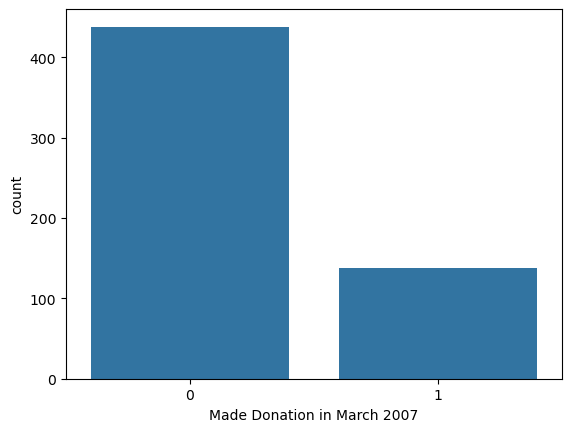

In [23]:
sns.countplot(x='Made Donation in March 2007', data=df)
plt.show()

This tells us:

How many donated

How many did not donate

Whether dataset is balanced or not

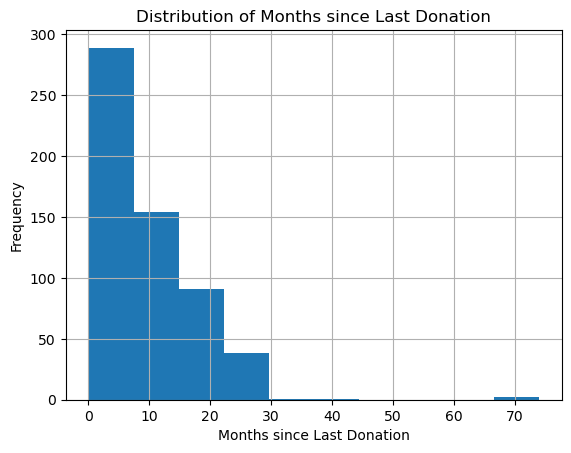

In [24]:
df['Months since Last Donation'].hist()
plt.xlabel('Months since Last Donation')
plt.ylabel('Frequency')
plt.title('Distribution of Months since Last Donation')
plt.show()

The distribution of “Months since Last Donation” shows that a large number of donors have donated recently, while fewer donors have a long gap since their last donation. This suggests that donor recency may play an important role in predicting repeat blood donation.

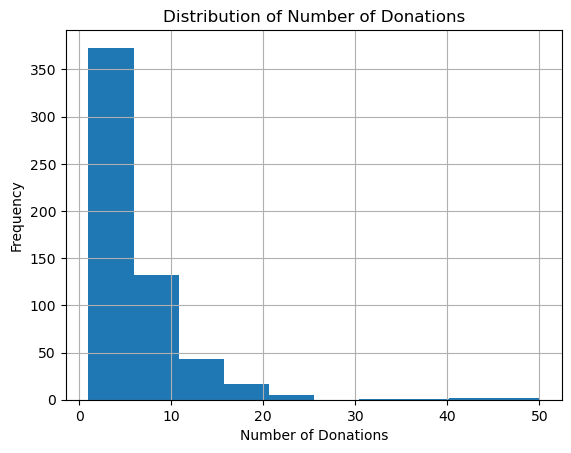

In [25]:
df['Number of Donations'].hist()
plt.xlabel('Number of Donations')
plt.ylabel('Frequency')
plt.title('Distribution of Number of Donations')
plt.show()

Most donors have made a small number of donations, while only a few donors have donated many times. This indicates that repeat donors are relatively fewer compared to first-time or occasional donors.

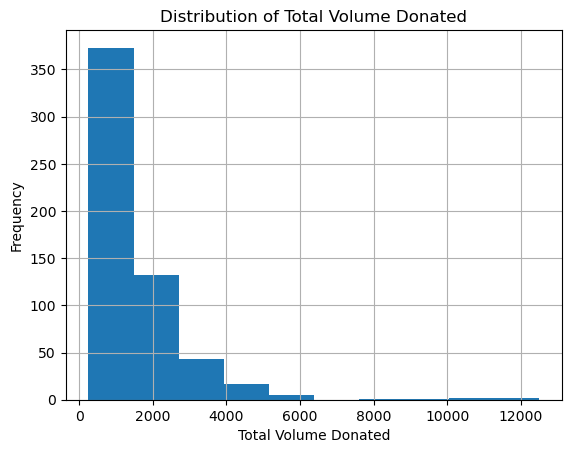

In [26]:
df['Total Volume Donated (c.c.)'].hist()
plt.xlabel('Total Volume Donated')
plt.ylabel('Frequency')
plt.title('Distribution of Total Volume Donated')
plt.show()

The total volume donated is higher for donors with multiple donations, while most donors have donated a smaller total volume. This pattern reflects the contribution difference between occasional and frequent donors.

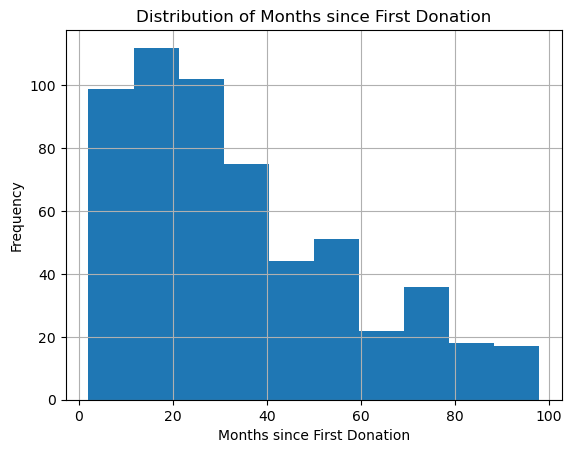

In [27]:
df['Months since First Donation'].hist()
plt.xlabel('Months since First Donation')
plt.ylabel('Frequency')
plt.title('Distribution of Months since First Donation')
plt.show()

The distribution of months since first donation indicates a mix of new and long-term donors, suggesting diversity in donor experience levels within the dataset.

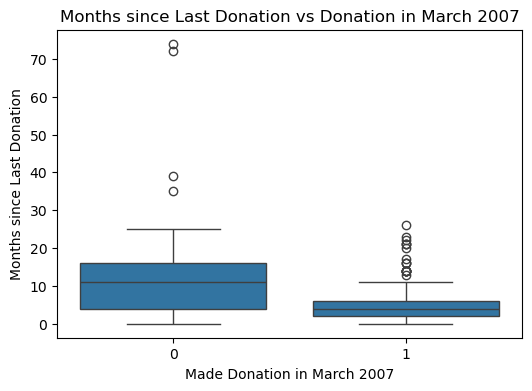

In [28]:
plt.figure(figsize=(6,4))
sns.boxplot(
    x='Made Donation in March 2007',
    y='Months since Last Donation',
    data=df
)
plt.xlabel('Made Donation in March 2007')
plt.ylabel('Months since Last Donation')
plt.title('Months since Last Donation vs Donation in March 2007')
plt.show()

Donors who donated in March 2007 tend to have fewer months since their last donation compared to those who did not donate. This highlights the importance of donor recency in predicting repeat blood donation.

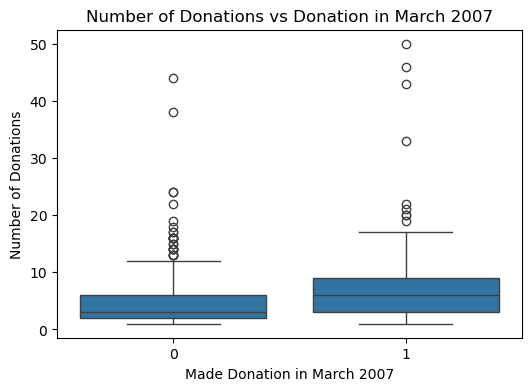

In [29]:
plt.figure(figsize=(6,4))
sns.boxplot(
    x='Made Donation in March 2007',
    y='Number of Donations',
    data=df
)
plt.xlabel('Made Donation in March 2007')
plt.ylabel('Number of Donations')
plt.title('Number of Donations vs Donation in March 2007')
plt.show()

The boxplot shows that donors who donated in March 2007 generally have a higher number of past donations compared to those who did not donate. This indicates that donors with a higher donation history are more likely to donate again, making “Number of Donations” an important predictive feature.

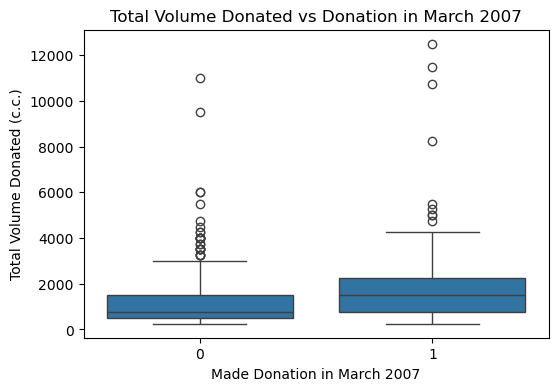

In [30]:
plt.figure(figsize=(6,4))
sns.boxplot(
    x='Made Donation in March 2007',
    y='Total Volume Donated (c.c.)',
    data=df
)
plt.xlabel('Made Donation in March 2007')
plt.ylabel('Total Volume Donated (c.c.)')
plt.title('Total Volume Donated vs Donation in March 2007')
plt.show()

The distribution of total volume donated is higher for donors who made a donation in March 2007 compared to those who did not. This suggests that donors who have contributed more blood in the past are more likely to be repeat donors.

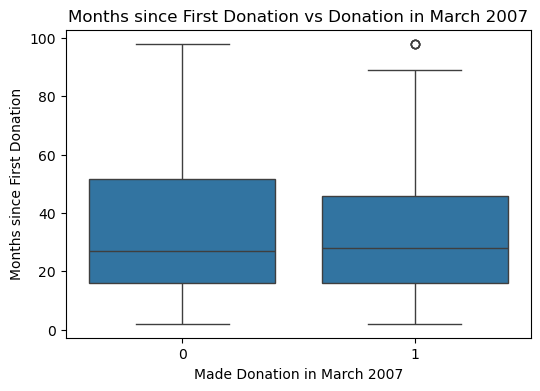

In [31]:
plt.figure(figsize=(6,4))
sns.boxplot(
    x='Made Donation in March 2007',
    y='Months since First Donation',
    data=df
)
plt.xlabel('Made Donation in March 2007')
plt.ylabel('Months since First Donation')
plt.title('Months since First Donation vs Donation in March 2007')
plt.show()

The boxplot indicates that donors who donated in March 2007 generally have a higher number of months since their first donation compared to those who did not donate. This suggests that long-term donors are more likely to continue donating blood, highlighting donor experience as an important factor in repeat donation behavior.

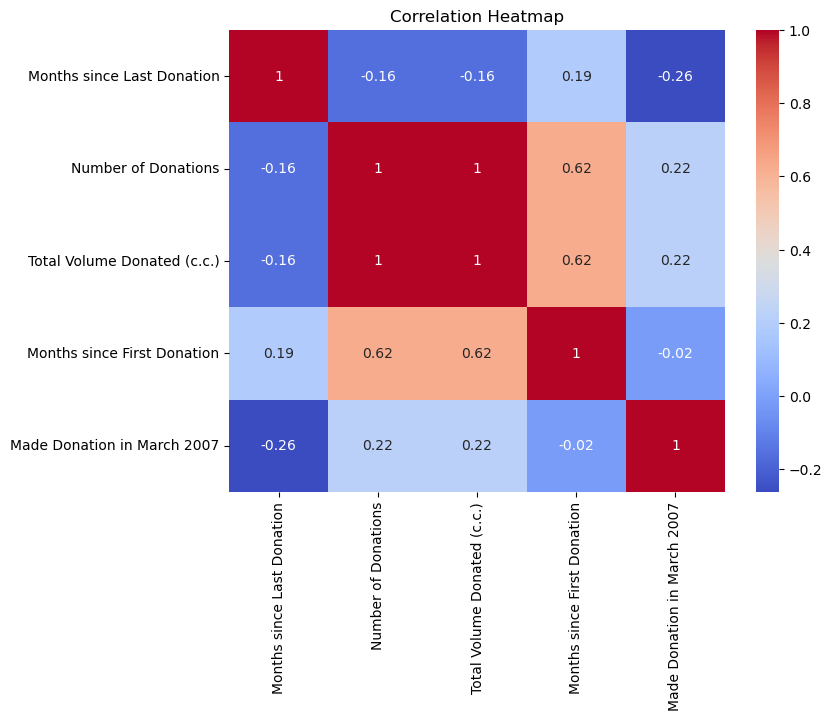

In [32]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

The correlation heatmap shows the relationship between different features in the dataset. A strong positive correlation is observed between “Number of Donations” and “Total Volume Donated”, which is expected as higher donations result in higher total volume. Additionally, features such as “Months since Last Donation” show a noticeable relationship with the target variable, indicating their importance in predicting repeat blood donation.

## Key Insights from Data Analysis

The dataset contains 576 donor records and is clean with no missing values.

The target variable shows that fewer donors donated in March 2007 compared to those who did not, indicating class imbalance.

Donors who donated recently are more likely to donate again.

Long-term donors with a higher number of donations show a higher probability of repeat donation.

“Number of Donations” and “Total Volume Donated” are strongly correlated, reflecting donor contribution behavior.

Overall, donor recency and donation history are important factors for predicting repeat blood donation.

In [33]:
X = df.drop(columns=['Made Donation in March 2007'])
y = df['Made Donation in March 2007']

The dataset was split into input features (X) and target variable (y). The target variable represents whether a donor donated blood in March 2007.

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

The dataset was split into training and testing sets using an 80–20 ratio. The training set is used to train the models, while the test set evaluates model performance on unseen data.

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.75
              precision    recall  f1-score   support

           0       0.75      0.99      0.86        87
           1       0.50      0.03      0.06        29

    accuracy                           0.75       116
   macro avg       0.63      0.51      0.46       116
weighted avg       0.69      0.75      0.66       116



In [36]:
y_pred_lr

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0])

In [37]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.6551724137931034
              precision    recall  f1-score   support

           0       0.78      0.75      0.76        87
           1       0.33      0.38      0.35        29

    accuracy                           0.66       116
   macro avg       0.56      0.56      0.56       116
weighted avg       0.67      0.66      0.66       116



Logistic Regression was used as a baseline classification model. It provides an interpretable approach for binary classification problems.

In [38]:
y_pred_dt

array([0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0])

In [39]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7155172413793104
              precision    recall  f1-score   support

           0       0.81      0.80      0.81        87
           1       0.43      0.45      0.44        29

    accuracy                           0.72       116
   macro avg       0.62      0.63      0.62       116
weighted avg       0.72      0.72      0.72       116



In [40]:
y_pred_rf

array([0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0])

In [41]:
from sklearn.metrics import accuracy_score
import pandas as pd

model_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ]
})

model_results

,Model,Accuracy
0,Logistic Regression,0.750000
1,Decision Tree,0.655172
2,Random Forest,0.715517


Model Selection:

Among the three trained models, Logistic Regression achieved the highest accuracy (75%) and was therefore selected as the final model for predicting blood donation behavior.

In [43]:
comparison = pd.DataFrame({
    'Actual Donation': y_test.values,
    'Predicted Donation': y_pred_lr
})

comparison.head(10)

,Actual Donation,Predicted Donation
0,0,0
1,0,0
2,0,0
3,0,0
4,1,0
5,1,0
6,0,0
7,1,0
8,0,0
9,0,0


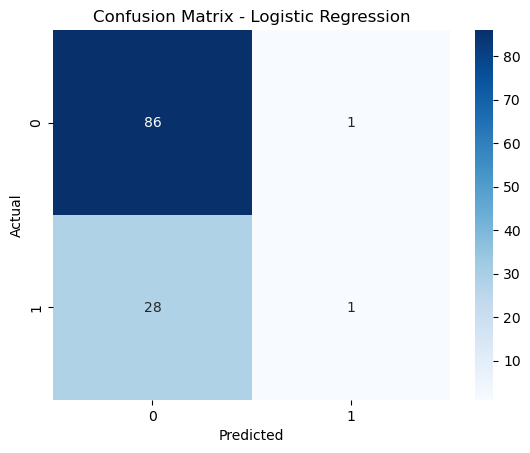

In [44]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

Model Evaluation:

The selected Logistic Regression model was evaluated using test data. The confusion matrix indicates that the model performs well in predicting non-donors, while predicting fewer donor cases due to class imbalance in the dataset. Overall, the model achieved an accuracy of 75%.

## Model Comparison Report

Three machine learning models—Logistic Regression, Decision Tree, and Random Forest—were trained and evaluated to predict blood donation behavior. Model performance was compared using accuracy.

Model	             Accuracy:
Logistic Regression	:   75%
Decision Tree	     :  65%
Random Forest	      : 71%

Logistic Regression achieved the highest accuracy and demonstrated better generalization compared to the other models. Therefore, it was selected as the final model for prediction.

## Challenges Faced During Model Development

During the development of the blood donation prediction model, several challenges were encountered:

### Class Imbalance:

The dataset contained a higher number of non-donors compared to donors. This imbalance caused the model to predict fewer donor cases, which required careful interpretation of results.

### Model Comparison:

Multiple models were trained (Logistic Regression, Decision Tree, Random Forest). Comparing performance and selecting the best model based on accuracy required detailed evaluation.

### Understanding Train-Test Split:

Initially, it was challenging to understand why predictions did not match the original dataset. This was clarified after understanding that predictions are made only on test data.

### Model Re-training Variations:

Accuracy values slightly changed when models were retrained, highlighting the importance of consistent training and evaluation procedures.

Overall, these challenges improved understanding of machine learning workflows and model evaluation techniques.

## Conclusion

In this project, machine learning techniques were used to predict blood donation behavior based on historical donor data. Multiple models were trained and compared, and Logistic Regression was selected as the final model due to its superior performance. The model demonstrated effective prediction capability and provided meaningful insights into donor behavior.